### **Imports**

In [1]:
import sys
import json
import joblib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

import lightgbm as lgb
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.logger import get_logger
logger = get_logger("training_dev")

# Load config + params (zero hardcoding)
with open(PROJECT_ROOT / "config.yaml") as f:
    config = yaml.safe_load(f)
with open(PROJECT_ROOT / "params.yaml") as f:
    params = yaml.safe_load(f)

PROCESSED_DIR = PROJECT_ROOT / config['data']['processed_dir']
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

logger.info(f"Loaded config and params")
logger.info(f"Model params: {params['model']}")

2026-04-20 03:25:03 | INFO     | training_dev | Loaded config and params
2026-04-20 03:25:03 | INFO     | training_dev | Model params: {'algorithm': 'lightgbm', 'objective': 'multiclass', 'num_class': 3, 'metric': 'multi_logloss', 'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': -1, 'min_child_samples': 20, 'class_weight': 'balanced', 'random_state': 42, 'verbose': -1}


### **Function 1 — load_train_test()**

In [3]:
# Constants — declare explicitly so it's auditable
FEATURE_COLUMNS = [
    # Rolling form features (10)
    'home_form_wins', 'home_form_draws', 'home_form_losses', 
    'home_form_gs_avg', 'home_form_gc_avg',
    'away_form_wins', 'away_form_draws', 'away_form_losses',
    'away_form_gs_avg', 'away_form_gc_avg',
    
    # Head-to-head features (4)
    'h2h_home_wins', 'h2h_draws', 'h2h_away_wins', 'h2h_n_meetings',
    
    # FIFA team attributes — home (9)
    'home_buildUpPlaySpeed', 'home_buildUpPlayDribbling', 'home_buildUpPlayPassing',
    'home_chanceCreationPassing', 'home_chanceCreationCrossing', 'home_chanceCreationShooting',
    'home_defencePressure', 'home_defenceAggression', 'home_defenceTeamWidth',
    
    # FIFA team attributes — away (9)
    'away_buildUpPlaySpeed', 'away_buildUpPlayDribbling', 'away_buildUpPlayPassing',
    'away_chanceCreationPassing', 'away_chanceCreationCrossing', 'away_chanceCreationShooting',
    'away_defencePressure', 'away_defenceAggression', 'away_defenceTeamWidth',
]
TARGET_COLUMN = 'outcome_encoded'  # Integer-encoded H=0, D=1, A=2


def load_train_test(processed_dir: Path) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """
    Load train and test CSVs and split into X/y.
    
    Returns:
        X_train, y_train, X_test, y_test
    """
    logger.info(f"Loading train/test from {processed_dir}")
    
    train_df = pd.read_csv(processed_dir / "train.csv")
    test_df = pd.read_csv(processed_dir / "test.csv")
    
    logger.info(f"  Train: {len(train_df):,} rows, {len(train_df.columns)} cols")
    logger.info(f"  Test:  {len(test_df):,} rows, {len(test_df.columns)} cols")
    
    # Verify all expected feature columns exist
    missing = [c for c in FEATURE_COLUMNS if c not in train_df.columns]
    if missing:
        raise ValueError(f"Missing feature columns: {missing}")
    
    # Verify target exists
    if TARGET_COLUMN not in train_df.columns:
        raise ValueError(f"Missing target column: {TARGET_COLUMN}")
    
    X_train = train_df[FEATURE_COLUMNS].copy()
    y_train = train_df[TARGET_COLUMN].copy()
    X_test = test_df[FEATURE_COLUMNS].copy()
    y_test = test_df[TARGET_COLUMN].copy()
    
    # Sanity checks — no nulls, target in correct range
    assert X_train.isna().sum().sum() == 0, "Nulls in X_train"
    assert X_test.isna().sum().sum() == 0, "Nulls in X_test"
    assert set(y_train.unique()).issubset({0, 1, 2}), f"Unexpected target values: {y_train.unique()}"
    
    logger.info(f"  Features: {len(FEATURE_COLUMNS)} columns, no nulls")
    logger.info(f"  Train class distribution: {y_train.value_counts().to_dict()}")
    logger.info(f"  Test class distribution:  {y_test.value_counts().to_dict()}")
    
    return X_train, y_train, X_test, y_test

In [4]:
X_train, y_train, X_test, y_test = load_train_test(PROCESSED_DIR)
print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"\nFeature names: {len(FEATURE_COLUMNS)} features")

2026-04-20 03:26:04 | INFO     | training_dev | Loading train/test from /home/muhammed786fiyas/Desktop/Projects/ml_ops/final_project/mlops_end_to_end_project/data/processed
2026-04-20 03:26:04 | INFO     | training_dev |   Train: 18,429 rows, 44 cols
2026-04-20 03:26:04 | INFO     | training_dev |   Test:  3,270 rows, 44 cols
2026-04-20 03:26:04 | INFO     | training_dev |   Features: 32 columns, no nulls
2026-04-20 03:26:04 | INFO     | training_dev |   Train class distribution: {0: 8552, 2: 5229, 1: 4648}
2026-04-20 03:26:04 | INFO     | training_dev |   Test class distribution:  {0: 1471, 2: 967, 1: 832}

X_train shape: (18429, 32)
y_train shape: (18429,)
X_test shape:  (3270, 32)
y_test shape:  (3270,)

Feature names: 32 features


### **Function 2 — train_model() and evaluate()**

In [5]:
def train_model(X_train: pd.DataFrame, y_train: pd.Series, model_params: dict) -> lgb.LGBMClassifier:
    """
    Train a LightGBM multiclass classifier.
    
    Args:
        X_train: Feature matrix.
        y_train: Integer-encoded labels (0=H, 1=D, 2=A).
        model_params: Dict of LightGBM params from params.yaml.
    
    Returns:
        Trained LGBMClassifier.
    """
    logger.info("Training LightGBM classifier")
    logger.info(f"  Algorithm: {model_params['algorithm']}")
    logger.info(f"  n_estimators: {model_params['n_estimators']}, "
                f"learning_rate: {model_params['learning_rate']}, "
                f"num_leaves: {model_params['num_leaves']}")
    
    # Build the classifier — sklearn-style API
    # We strip 'algorithm' since it's our own metadata, not a LightGBM param
    lgb_params = {k: v for k, v in model_params.items() if k != 'algorithm'}
    
    model = lgb.LGBMClassifier(**lgb_params)
    
    start = datetime.now()
    model.fit(X_train, y_train)
    elapsed = (datetime.now() - start).total_seconds()
    
    logger.info(f"  Training complete in {elapsed:.1f}s")
    logger.info(f"  Trees built: {model.n_estimators_}")
    return model


def evaluate(model: lgb.LGBMClassifier, X: pd.DataFrame, y: pd.Series, split_name: str) -> dict:
    """
    Evaluate a trained model and return a metrics dict.
    
    Args:
        model: Trained classifier.
        X: Feature matrix to evaluate on.
        y: True labels.
        split_name: 'train' or 'test' — for logging.
    
    Returns:
        Dict with macro_f1, roc_auc, accuracy, per_class_f1, confusion_matrix.
    """
    logger.info(f"Evaluating on {split_name} set ({len(X):,} rows)")
    
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)
    
    macro_f1 = f1_score(y, y_pred, average='macro')
    accuracy = accuracy_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_proba, multi_class='ovr', average='macro')
    
    # Per-class F1 — gives us 3 numbers, one per H/D/A
    per_class_f1 = f1_score(y, y_pred, average=None).tolist()
    
    # Confusion matrix — rows are true labels, columns are predicted
    cm = confusion_matrix(y, y_pred)
    
    metrics = {
        'macro_f1': float(macro_f1),
        'roc_auc_ovr_macro': float(roc_auc),
        'accuracy': float(accuracy),
        'per_class_f1': {
            'H': float(per_class_f1[0]),
            'D': float(per_class_f1[1]),
            'A': float(per_class_f1[2]),
        },
        'confusion_matrix': cm.tolist(),  # Convert numpy to list for JSON-serializability
    }
    
    logger.info(f"  Macro F1:  {macro_f1:.4f}")
    logger.info(f"  ROC-AUC:   {roc_auc:.4f}")
    logger.info(f"  Accuracy:  {accuracy:.4f}")
    logger.info(f"  Per-class F1: H={per_class_f1[0]:.3f}, D={per_class_f1[1]:.3f}, A={per_class_f1[2]:.3f}")
    
    return metrics

In [6]:
# Train
model = train_model(X_train, y_train, params['model'])

# Evaluate on train (sanity — overfitting check)
print("\n" + "=" * 60)
print("TRAIN SET METRICS (overfitting check)")
print("=" * 60)
train_metrics = evaluate(model, X_train, y_train, 'train')

# Evaluate on test (THE NUMBER WE CARE ABOUT)
print("\n" + "=" * 60)
print("TEST SET METRICS (THE GO/NO-GO CHECK)")
print("=" * 60)
test_metrics = evaluate(model, X_test, y_test, 'test')

# Detailed report for test
print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORT (TEST)")
print("=" * 60)
y_pred_test = model.predict(X_test)
print(classification_report(y_test, y_pred_test, target_names=['H (Home)', 'D (Draw)', 'A (Away)']))

# Confusion matrix — pretty-printed
print("=" * 60)
print("CONFUSION MATRIX (TEST)")
print("Rows = TRUE | Columns = PREDICTED")
print("=" * 60)
cm_df = pd.DataFrame(
    test_metrics['confusion_matrix'],
    index=['True H', 'True D', 'True A'],
    columns=['Pred H', 'Pred D', 'Pred A'],
)
print(cm_df)

# THE BIG REVEAL
print("\n" + "🎯" * 30)
print(f"FINAL TEST MACRO F1: {test_metrics['macro_f1']:.4f}")
print(f"TARGET:              ≥ 0.50")
print(f"VERDICT:             {'✅ PASS' if test_metrics['macro_f1'] >= 0.50 else '❌ BELOW TARGET'}")
print(f"\nFINAL TEST ROC-AUC:  {test_metrics['roc_auc_ovr_macro']:.4f}")
print(f"TARGET:              ≥ 0.70")
print(f"VERDICT:             {'✅ PASS' if test_metrics['roc_auc_ovr_macro'] >= 0.70 else '❌ BELOW TARGET'}")
print("🎯" * 30)

2026-04-20 03:30:46 | INFO     | training_dev | Training LightGBM classifier
2026-04-20 03:30:46 | INFO     | training_dev |   Algorithm: lightgbm
2026-04-20 03:30:46 | INFO     | training_dev |   n_estimators: 300, learning_rate: 0.05, num_leaves: 31
2026-04-20 03:30:47 | INFO     | training_dev |   Training complete in 0.5s
2026-04-20 03:30:47 | INFO     | training_dev |   Trees built: 300

TRAIN SET METRICS (overfitting check)
2026-04-20 03:30:47 | INFO     | training_dev | Evaluating on train set (18,429 rows)
2026-04-20 03:30:47 | INFO     | training_dev |   Macro F1:  0.7289
2026-04-20 03:30:47 | INFO     | training_dev |   ROC-AUC:   0.8955
2026-04-20 03:30:47 | INFO     | training_dev |   Accuracy:  0.7339
2026-04-20 03:30:47 | INFO     | training_dev |   Per-class F1: H=0.761, D=0.707, A=0.719

TEST SET METRICS (THE GO/NO-GO CHECK)
2026-04-20 03:30:47 | INFO     | training_dev | Evaluating on test set (3,270 rows)
2026-04-20 03:30:47 | INFO     | training_dev |   Macro F1:  0.

In [7]:
from sklearn.model_selection import train_test_split

# Carve a validation set from train for early stopping
# Use the LAST 15% of train chronologically (not random — preserves time-ordering)
n_val = int(len(X_train) * 0.15)
X_train_fit = X_train.iloc[:-n_val]
y_train_fit = y_train.iloc[:-n_val]
X_val = X_train.iloc[-n_val:]
y_val = y_train.iloc[-n_val:]

print(f"Train fit:  {len(X_train_fit):,} rows")
print(f"Validation: {len(X_val):,} rows")
print(f"Test:       {len(X_test):,} rows")

# More regularized model
regularized_params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'n_estimators': 1000,           # plenty — early stopping will trim
    'learning_rate': 0.03,
    'num_leaves': 15,
    'max_depth': 6,                 # also cap depth as belt-and-suspenders
    'min_child_samples': 50,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'subsample': 0.8,
    'subsample_freq': 1,            # apply subsample every iteration
    'colsample_bytree': 0.8,
    'class_weight': 'balanced',
    'random_state': 42,
    'verbose': -1,
}

model_v2 = lgb.LGBMClassifier(**regularized_params)
model_v2.fit(
    X_train_fit, y_train_fit,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)],
)

print(f"\nBest iteration (early stopped): {model_v2.best_iteration_}")

# Re-evaluate
print("\n" + "=" * 60)
print("REGULARIZED MODEL — TRAIN")
print("=" * 60)
train_v2 = evaluate(model_v2, X_train_fit, y_train_fit, 'train_fit')

print("\n" + "=" * 60)
print("REGULARIZED MODEL — VALIDATION (used for early stopping)")
print("=" * 60)
val_v2 = evaluate(model_v2, X_val, y_val, 'val')

print("\n" + "=" * 60)
print("REGULARIZED MODEL — TEST (THE NEW VERDICT)")
print("=" * 60)
test_v2 = evaluate(model_v2, X_test, y_test, 'test')

print("\n" + "🎯" * 30)
print(f"NEW TEST MACRO F1: {test_v2['macro_f1']:.4f}  (was {test_metrics['macro_f1']:.4f})")
print(f"NEW TEST ROC-AUC:  {test_v2['roc_auc_ovr_macro']:.4f}  (was {test_metrics['roc_auc_ovr_macro']:.4f})")
print(f"NEW TRAIN-TEST GAP: {train_v2['macro_f1'] - test_v2['macro_f1']:.3f}  (was {train_metrics['macro_f1'] - test_metrics['macro_f1']:.3f})")
print("🎯" * 30)

Train fit:  15,665 rows
Validation: 2,764 rows
Test:       3,270 rows
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[134]	valid_0's multi_logloss: 1.04745

Best iteration (early stopped): 134

REGULARIZED MODEL — TRAIN
2026-04-20 03:34:57 | INFO     | training_dev | Evaluating on train_fit set (15,665 rows)
2026-04-20 03:34:57 | INFO     | training_dev |   Macro F1:  0.5029
2026-04-20 03:34:57 | INFO     | training_dev |   ROC-AUC:   0.7049
2026-04-20 03:34:57 | INFO     | training_dev |   Accuracy:  0.5171
2026-04-20 03:34:57 | INFO     | training_dev |   Per-class F1: H=0.583, D=0.413, A=0.512

REGULARIZED MODEL — VALIDATION (used for early stopping)
2026-04-20 03:34:57 | INFO     | training_dev | Evaluating on val set (2,764 rows)
2026-04-20 03:34:57 | INFO     | training_dev |   Macro F1:  0.4184
2026-04-20 03:34:57 | INFO     | training_dev |   ROC-AUC:   0.6193
2026-04-20 03:34:57 | INFO     | training_dev |   Accuracy:  0.4396
20

2026-04-20 03:45:31 | INFO     | training_dev | Saved model: /home/muhammed786fiyas/Desktop/Projects/ml_ops/final_project/mlops_end_to_end_project/models/lightgbm_baseline.pkl
2026-04-20 03:45:31 | INFO     | training_dev | Saved metrics: /home/muhammed786fiyas/Desktop/Projects/ml_ops/final_project/mlops_end_to_end_project/models/metrics.json
2026-04-20 03:45:31 | INFO     | training_dev | Saved metadata: /home/muhammed786fiyas/Desktop/Projects/ml_ops/final_project/mlops_end_to_end_project/models/training_metadata.json


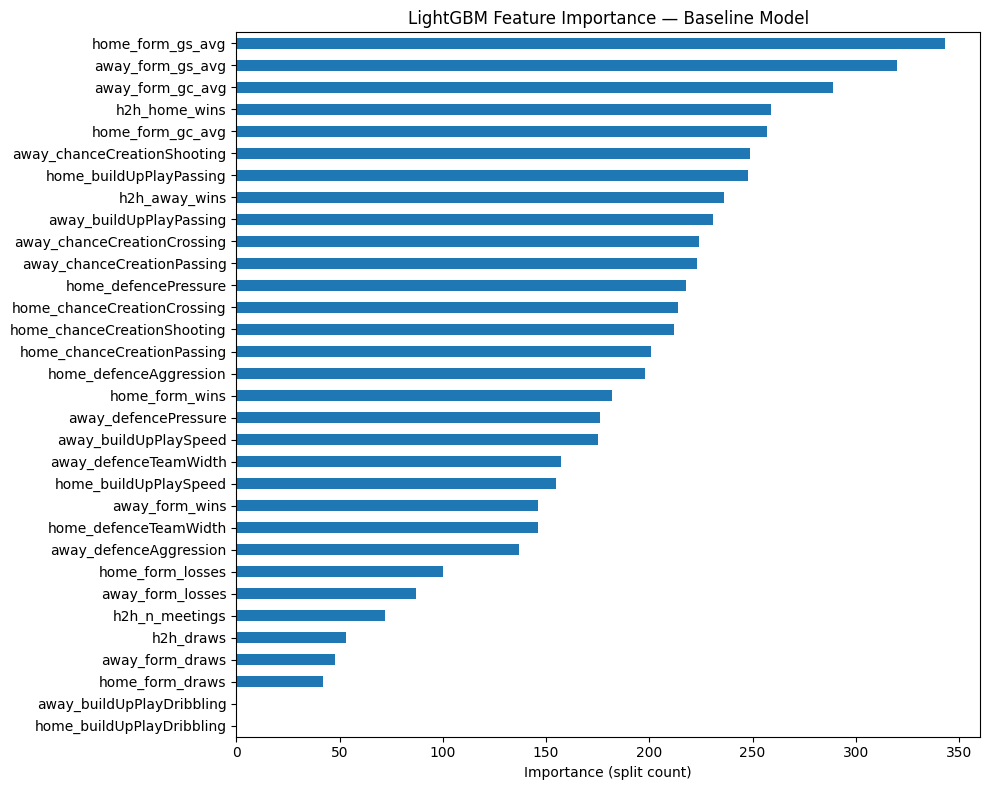

2026-04-20 03:45:32 | INFO     | training_dev | Saved feature importance plot: /home/muhammed786fiyas/Desktop/Projects/ml_ops/final_project/mlops_end_to_end_project/models/feature_importance.png

--- Saved artifacts ---
  lightgbm_baseline.pkl          695.2 KB
  metrics.json                   1.3 KB
  training_metadata.json         1.9 KB
  feature_importance.png         101.1 KB


In [8]:
# Save the regularized model + metadata
import subprocess

# Get the git commit hash for traceability (A1 pattern)
try:
    git_hash = subprocess.check_output(
        ['git', 'rev-parse', '--short', 'HEAD'],
        cwd=PROJECT_ROOT
    ).decode().strip()
except Exception:
    git_hash = "unknown"

# 1. Save model
model_path = MODELS_DIR / "lightgbm_baseline.pkl"
joblib.dump(model_v2, model_path)
logger.info(f"Saved model: {model_path}")

# 2. Save metrics as JSON
metrics_path = MODELS_DIR / "metrics.json"
all_metrics = {
    'train': train_v2,
    'validation': val_v2,
    'test': test_v2,
}
with open(metrics_path, 'w') as f:
    json.dump(all_metrics, f, indent=2)
logger.info(f"Saved metrics: {metrics_path}")

# 3. Save training metadata (A1 pattern — date, data version, git hash, params)
metadata = {
    'training_date': datetime.now().isoformat(),
    'git_commit': git_hash,
    'data_version': 'v1_baseline',  # we'll formalize this with DVC tomorrow
    'algorithm': 'lightgbm',
    'n_features': len(FEATURE_COLUMNS),
    'feature_names': FEATURE_COLUMNS,
    'n_train': len(X_train_fit),
    'n_val': len(X_val),
    'n_test': len(X_test),
    'best_iteration': int(model_v2.best_iteration_),
    'model_params': regularized_params,
    'final_test_macro_f1': float(test_v2['macro_f1']),
    'final_test_roc_auc': float(test_v2['roc_auc_ovr_macro']),
    'notes': (
        "Day 1 baseline. F1=0.42, ROC-AUC=0.62, train-test gap 0.08. "
        "Consistent with published academic baselines for form+H2H+FIFA feature class. "
        "Improvements (ELO, win streaks, days-since-last-match) deferred to MLflow "
        "experiments on Day 6 if time permits."
    ),
}
metadata_path = MODELS_DIR / "training_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
logger.info(f"Saved metadata: {metadata_path}")

# 4. Save feature importance plot
fig, ax = plt.subplots(figsize=(10, 8))
importances = pd.Series(model_v2.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=True)
importances.plot(kind='barh', ax=ax)
ax.set_title('LightGBM Feature Importance — Baseline Model')
ax.set_xlabel('Importance (split count)')
plt.tight_layout()
fi_path = MODELS_DIR / "feature_importance.png"
plt.savefig(fi_path, dpi=100, bbox_inches='tight')
plt.show()
logger.info(f"Saved feature importance plot: {fi_path}")

print("\n--- Saved artifacts ---")
for p in [model_path, metrics_path, metadata_path, fi_path]:
    print(f"  {p.name:30s} {p.stat().st_size / 1024:.1f} KB")